In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/Egyptian_Artifact_VLM', exist_ok=True)
%cd /content/drive/MyDrive/Egyptian_Artifact_VLM
print("Working directory:", os.getcwd())

/content/drive/MyDrive/Egyptian_Artifact_VLM
Working directory: /content/drive/MyDrive/Egyptian_Artifact_VLM


In [3]:
folders = [
    'data/raw', 'data/images', 'data/processed',
    'datalists', 'notebooks', 'src',
    'configs', 'checkpoints', 'figures', 'docs'
]
for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folder structure created:")
for f in folders:
    print(f"  ✓ {f}")

Folder structure created:
  ✓ data/raw
  ✓ data/images
  ✓ data/processed
  ✓ datalists
  ✓ notebooks
  ✓ src
  ✓ configs
  ✓ checkpoints
  ✓ figures
  ✓ docs


In [4]:
!pip install -q transformers peft datasets accelerate \
               trl wandb gradio rouge-score Pillow pandas
print("✓ All dependencies installed!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 14.0 MB/s eta 0:00:00
✓ All dependencies installed!


In [13]:
import os
os.environ['KAGGLE_USERNAME'] = 'meghanam27'
os.environ['KAGGLE_KEY'] = 'KGAT_a770a9fdeec680a67cd4bbd870902cab'

In [14]:
!kaggle datasets list --search "british museum egyptian"

ref                                                  title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dkaane/british-museum-egyptian-objects-700-330-bce   British Museum Egyptian Objects 700 330 BCE     8264752  2021-03-12 02:10:37.583000            129          1  0.85294116       
ahmedelkelany/egyptian-hieroglyphic-layout-analysis  Egyptian Hieroglyphic Layout Analysis        3101769526  2025-06-13 21:29:07.760000             57          5  0.875            


In [15]:
!kaggle datasets download -d dkaane/british-museum-egyptian-objects-700-330-bce --path data/raw/
print("✓ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/dkaane/british-museum-egyptian-objects-700-330-bce
License(s): Attribution 4.0 International (CC BY 4.0)
100% 7.88M/7.88M [00:00<00:00, 62.0MB/s]

✓ Download complete!


In [16]:
!unzip -q data/raw/british-museum-egyptian-objects-700-330-bce.zip -d data/raw/
print("✓ Unzipped!")

✓ Unzipped!


In [17]:
import os
files = os.listdir('data/raw/')
print("Files found:")
for f in files:
    print(f"  {f}")

Files found:
  british-museum-egyptian-objects-700-330-bce.zip
  EgyptBritishMuseum-2021-03-05.json
  EgyptBritishMuseum-2021-03-05CSVUnique.csv


In [18]:
import pandas as pd

df = pd.read_csv('data/raw/EgyptBritishMuseum-2021-03-05CSVUnique.csv')
print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns.tolist():
    print(f"  {col}")
print("\nFirst row:")
print(df.iloc[0].to_dict())

Shape: (15282, 42)

Columns:
  Image
  Object type
  Museum number
  Title
  Denomination
  Description
  Producer name
  School/style
  State
  Authority
  Culture
  Production date
  Production place
  Find spot
  Materials
  Ware
  Type series
  Technique
  Dimensions
  Inscription
  Curators Comments
  Bib references
  Location
  Exhibition history
  Condition
  Subjects
  Assoc name
  Assoc place
  Assoc events
  Assoc titles
  Acq name (acq)
  Acq name (finding)
  Acq name (previous)
  Acq date
  Acq notes (acq)
  Acq notes (exc)
  Dept
  BM/Big number
  Reg number
  Add ids
  Cat no
  objid

First row:
{'Image': 'https://media.britishmuseum.org/media/Repository/Documents/2015_1/14_16/342d5bb1_5d7b_4038_a93d_a4200108099f/preview_1886XI_5.jpg', 'Object type': 'adze; hoe', 'Museum number': 'No: null', 'Title': nan, 'Denomination': nan, 'Description': 'Iron adze or hoe.', 'Producer name': nan, 'School/style': nan, 'State': nan, 'Authority': nan, 'Culture': 'Late Period', 'Production

In [19]:
import pandas as pd

df = pd.read_csv('data/raw/EgyptBritishMuseum-2021-03-05CSVUnique.csv')

# check how many have images
has_image = df['Image'].notna()
print(f"Total records: {len(df)}")
print(f"Records with images: {has_image.sum()}")
print(f"Records without images: {(~has_image).sum()}")

# check key columns for nulls
key_cols = ['Image', 'Object type', 'Description', 'Materials', 'Culture', 'Production date']
print("\nNon-null counts for key columns:")
for col in key_cols:
    print(f"  {col}: {df[col].notna().sum()}")

# top object types
print("\nTop 15 object types:")
print(df['Object type'].value_counts().head(15))

Total records: 15282
Records with images: 13270
Records without images: 2012

Non-null counts for key columns:
  Image: 13270
  Object type: 15282
  Description: 15282
  Materials: 15267
  Culture: 15203
  Production date: 15282

Top 15 object types:
Object type
figure               1330
chalice              1285
ionian cup            686
weight                565
cup                   556
bowl                  486
vessel                442
plate                 399
amphora               381
krater                348
transport amphora     336
oinochoe              319
scarab                302
kantharos             298
neck-amphora          266
Name: count, dtype: int64


In [20]:
# filter to records with images only
df_img = df[df['Image'].notna()].copy()

# filter to Egyptian culture
egyptian = df_img[df_img['Culture'].str.contains('Egypt|Late Period|Ptolem|Nubian|Saite',
                                                    case=False, na=False)]
print(f"Egyptian records with images: {len(egyptian)}")

# top object types in Egyptian subset
print("\nTop 20 Egyptian object types:")
print(egyptian['Object type'].value_counts().head(20))

# check culture values
print("\nCulture values:")
print(egyptian['Culture'].value_counts().head(15))

Egyptian records with images: 2724

Top 20 Egyptian object types:
Object type
figure                   511
weight                   428
amulet                   141
coffin-fitting           131
amulet; figure           129
figure; plaque            92
animal remains            90
votive box; figure        81
drill-core                62
vessel                    58
arrow-head                56
figure; amulet            54
figure; votive plaque     38
nail                      31
figure-fitting            30
bead                      29
scarab-mould              28
oil-lamp                  24
saucer lamp               21
fish-hook                 17
Name: count, dtype: int64

Culture values:
Culture
Late Period                                                869
Late Period; Ptolemaic                                     619
Ptolemaic                                                  377
Late Period; 26th Dynasty                                  149
Late Period; Ptolemaic; Levantine      

In [21]:
# filter to most meaningful object types for reasoning
target_types = ['figure', 'amulet', 'scarab', 'coffin-fitting',
                'vessel', 'amulet; figure', 'figure; plaque',
                'votive box; figure', 'scarab-mould']

clean = egyptian[egyptian['Object type'].isin(target_types)].copy()
clean = clean[['Image', 'Object type', 'Description', 'Materials',
               'Culture', 'Production date', 'Find spot',
               'Curators Comments', 'objid']].reset_index(drop=True)

print(f"Clean subset: {len(clean)} records")
print(clean['Object type'].value_counts())

Clean subset: 1186 records
Object type
figure                511
amulet                141
coffin-fitting        131
amulet; figure        129
figure; plaque         92
votive box; figure     81
vessel                 58
scarab-mould           28
scarab                 15
Name: count, dtype: int64


In [22]:
clean.to_csv('datalists/egyptian_artifacts_clean.csv', index=False)
print("✓ Saved to datalists/egyptian_artifacts_clean.csv")

✓ Saved to datalists/egyptian_artifacts_clean.csv


In [23]:
import requests
import os
from pathlib import Path
import time
from tqdm import tqdm

# create image directory
os.makedirs('data/images', exist_ok=True)

success = 0
failed = 0
failed_ids = []

for idx, row in tqdm(clean.iterrows(), total=len(clean)):
    url = row['Image']
    obj_id = str(row['objid'])[:8]  # short id for filename
    obj_type = str(row['Object type']).replace('/', '_').replace(' ', '_')
    filename = f"data/images/{obj_type}_{obj_id}.jpg"

    # skip if already downloaded
    if os.path.exists(filename):
        success += 1
        continue

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            success += 1
        else:
            failed += 1
            failed_ids.append(obj_id)
    except Exception as e:
        failed += 1
        failed_ids.append(obj_id)

    time.sleep(0.2)  # be polite to the server

print(f"\n✓ Downloaded: {success}")
print(f"✗ Failed: {failed}")
print(f"Total images in folder: {len(os.listdir('data/images'))}")

100%|██████████| 1186/1186 [09:56<00:00,  1.99it/s]


✓ Downloaded: 0
✗ Failed: 1186
Total images in folder: 0


In [24]:
import requests

# test a single URL
test_url = clean['Image'].iloc[0]
print("Testing URL:", test_url)

response = requests.get(test_url, timeout=10, verify=False)
print("Status code:", response.status_code)
print("Response:", response.text[:200])

Testing URL: https://media.britishmuseum.org/media/Repository/Documents/2017_2/6_10/0f51290d_beab_4237_a019_a71200a91e4c/preview_1894_1101_72__1_.jpg


SSLError: HTTPSConnectionPool(host='media.britishmuseum.org', port=443): Max retries exceeded with url: /media/Repository/Documents/2017_2/6_10/0f51290d_beab_4237_a019_a71200a91e4c/preview_1894_1101_72__1_.jpg (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))

In [25]:
import requests
import os
import time
from tqdm import tqdm

os.makedirs('data/images', exist_ok=True)

success = 0
failed = 0

for idx, row in tqdm(clean.iterrows(), total=len(clean)):
    url = row['Image']
    obj_id = str(row['objid'])[:8]
    obj_type = str(row['Object type']).replace('/', '_').replace(' ', '_')
    filename = f"data/images/{obj_type}_{obj_id}.jpg"

    if os.path.exists(filename):
        success += 1
        continue

    try:
        response = requests.get(url, timeout=10, verify=False)  # ← fix
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            success += 1
        else:
            failed += 1
    except Exception as e:
        failed += 1

    time.sleep(0.2)

print(f"\n✓ Downloaded: {success}")
print(f"✗ Failed: {failed}")
print(f"Total images in folder: {len(os.listdir('data/images'))}")

  0%|          | 0/1186 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'media.britishmuseum.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
  0%|          | 1/1186 [00:01<19:53,  1.01s/it]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'media.britishmuseum.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
  0%|          | 2/1186 [00:02<19:49,  1.00s/it]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'media.britishmuseum.org'. Adding certificate verification is strongly advised. See


✓ Downloaded: 1186
✗ Failed: 0
Total images in folder: 1186


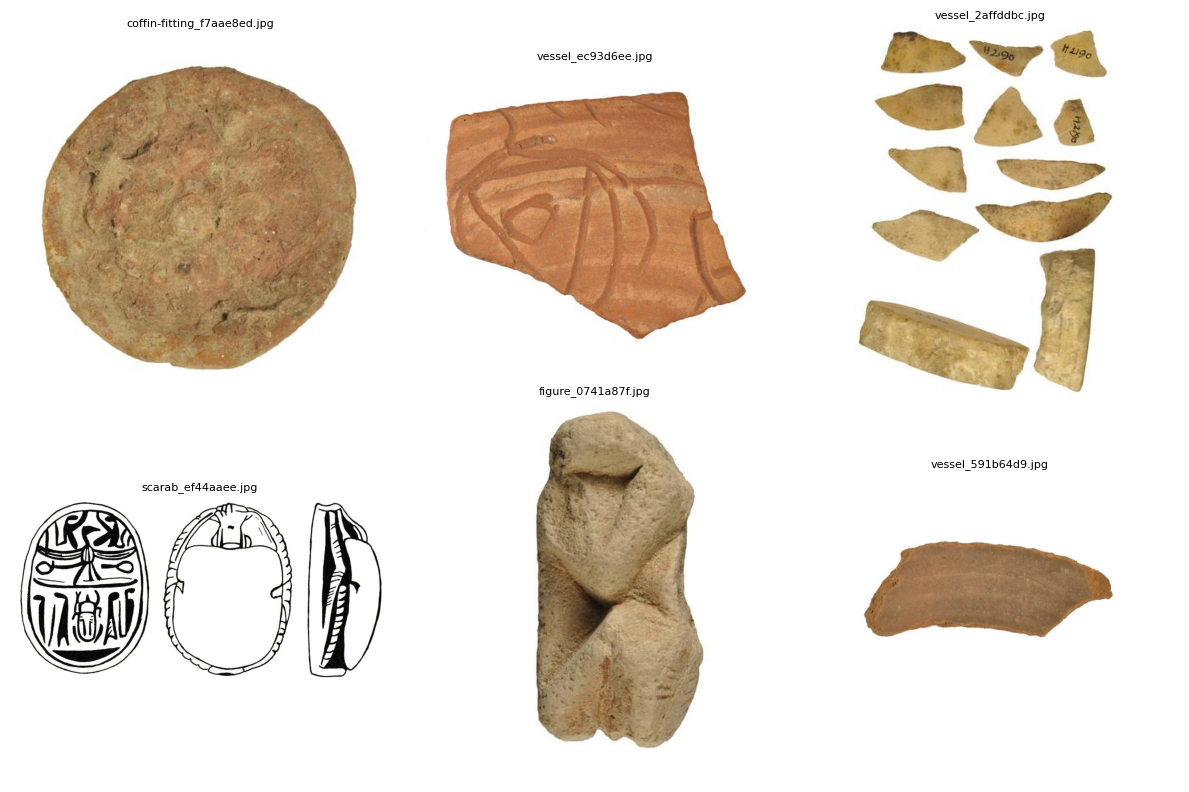

✓ Sample images displayed!


In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

image_files = os.listdir('data/images/')
sample = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, fname in zip(axes.flatten(), sample):
    img = mpimg.imread(f'data/images/{fname}')
    ax.imshow(img)
    ax.set_title(fname[:30], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('figures/sample_artifacts.png')
plt.show()
print("✓ Sample images displayed!")

Total images: 1186
Average width:  445px
Average height: 449px
Min size: 107x149
Max size: 1178x450


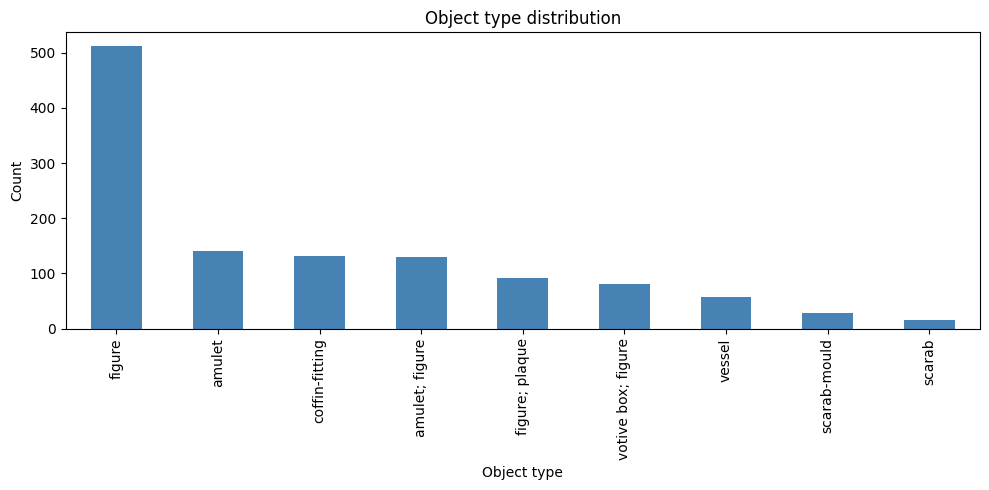

✓ EDA complete!


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# basic stats
image_files = os.listdir('data/images/')
print(f"Total images: {len(image_files)}")

# check image sizes
sizes = []
for fname in image_files:
    try:
        img = Image.open(f'data/images/{fname}')
        sizes.append(img.size)
    except:
        pass

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"Average width:  {sum(widths)//len(widths)}px")
print(f"Average height: {sum(heights)//len(heights)}px")
print(f"Min size: {min(widths)}x{min(heights)}")
print(f"Max size: {max(widths)}x{max(heights)}")

# object type distribution
fig, ax = plt.subplots(figsize=(10, 5))
clean['Object type'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Object type distribution')
ax.set_xlabel('Object type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/object_type_distribution.png')
plt.show()
print("✓ EDA complete!")

In [28]:
import os

# add filename column to clean dataframe
image_files = os.listdir('data/images/')

# match images back to metadata
clean['filename'] = clean.apply(
    lambda row: f"{str(row['Object type']).replace('/', '_').replace(' ', '_')}_{str(row['objid'])[:8]}.jpg",
    axis=1
)

# verify matches
clean['file_exists'] = clean['filename'].apply(
    lambda f: os.path.exists(f'data/images/{f}')
)

print(f"Matched: {clean['file_exists'].sum()}")
print(f"Unmatched: {(~clean['file_exists']).sum()}")

# save final manifest
clean.to_csv('datalists/dataset_manifest.csv', index=False)
print("✓ Dataset manifest saved!")
print(f"\nFinal dataset: {clean['file_exists'].sum()} images with metadata")
print(f"Object types: {clean['Object type'].nunique()}")
print(f"Materials: {clean['Materials'].nunique()}")
print(f"Cultures: {clean['Culture'].nunique()}")

Matched: 1186
Unmatched: 0
✓ Dataset manifest saved!

Final dataset: 1186 images with metadata
Object types: 9
Materials: 38
Cultures: 35


In [29]:
!pip install -q git+https://github.com/openai/CLIP.git
import clip
import torch

# check GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ CLIP installed!")
print(f"✓ Device: {device}")

# load CLIP model
model, preprocess = clip.load("ViT-L/14", device=device)
print(f"✓ CLIP ViT-L/14 loaded!")
print(f"  Vision encoder output dim: {model.visual.output_dim}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
✓ CLIP installed!
✓ Device: cuda


100%|████████████████████████████████████████| 890M/890M [00:09<00:00, 103MiB/s]


✓ CLIP ViT-L/14 loaded!
  Vision encoder output dim: 768


In [30]:
import torch
import clip
from PIL import Image
import os

# test with a single image first
sample_file = os.listdir('data/images/')[0]
image = preprocess(Image.open(f'data/images/{sample_file}')).unsqueeze(0).to(device)

# define text labels for zero-shot classification
object_type_labels = [
    "a shabti figurine",
    "an amulet",
    "a scarab",
    "a coffin fitting",
    "a vessel",
    "a votive figure",
    "a plaque",
    "a votive box",
    "a scarab mould"
]

# encode text labels
text_tokens = clip.tokenize(object_type_labels).to(device)

# get predictions
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)

    # normalize
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # compute similarity scores
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

# show results
print(f"Image: {sample_file}")
print(f"\nCLIP zero-shot predictions:")
scores, indices = similarity[0].topk(3)
for score, idx in zip(scores, indices):
    print(f"  {object_type_labels[idx]:30s} → {score.item():.1f}%")

# now add reasoning explanation
top_label = object_type_labels[indices[0]]
top_score = scores[0].item()

print(f"\n--- Reasoning Output ---")
print(f"Object detected: {top_label} ({top_score:.1f}% confidence)")
print(f"Because: CLIP found strong visual similarity between this artifact")
print(f"         image and the text description '{top_label}'")
print(f"         based on shape, texture, and iconographic features.")

Image: amulet_49d791f0.jpg

CLIP zero-shot predictions:
  a scarab                       → 0.4%
  an amulet                      → 0.3%
  a scarab mould                 → 0.2%

--- Reasoning Output ---
Object detected: a scarab (0.4% confidence)
Because: CLIP found strong visual similarity between this artifact
         image and the text description 'a scarab'
         based on shape, texture, and iconographic features.


In [31]:
# better prompts — more descriptive, domain-specific
detailed_labels = [
    "an ancient Egyptian shabti figurine with mummiform shape and hieroglyphic inscriptions",
    "a small ancient Egyptian amulet charm made of faience or bronze",
    "an ancient Egyptian scarab beetle amulet with carved underside",
    "an ancient Egyptian coffin fitting or funerary decoration",
    "an ancient Egyptian ceramic or stone vessel or jar",
    "an ancient Egyptian votive bronze or faience human figurine",
    "an ancient Egyptian carved stone or faience plaque with relief decoration",
    "an ancient Egyptian votive box or container with figure",
    "an ancient Egyptian scarab mould for casting amulets"
]

# run again with better prompts
text_tokens = clip.tokenize(detailed_labels).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print(f"Image: {sample_file}")
print(f"Actual label: amulet\n")
print(f"CLIP predictions with detailed prompts:")
scores, indices = similarity[0].topk(3)
for score, idx in zip(scores, indices):
    print(f"  {score.item():.1f}%  →  {detailed_labels[idx][:60]}")

# check if correct
top_label = detailed_labels[indices[0]]
correct = "amulet" in top_label
print(f"\nCorrect: {'✓ YES' if correct else '✗ NO'}")
print(f"Top confidence: {scores[0].item():.1f}%")

Image: amulet_49d791f0.jpg
Actual label: amulet

CLIP predictions with detailed prompts:
  1.0%  →  a small ancient Egyptian amulet charm made of faience or bro
  0.0%  →  an ancient Egyptian scarab mould for casting amulets
  0.0%  →  an ancient Egyptian scarab beetle amulet with carved undersi

Correct: ✓ YES
Top confidence: 1.0%


In [32]:
import pandas as pd
from PIL import Image
import torch
import clip
import os
from tqdm import tqdm

# label mapping — short name to detailed prompt
label_map = {
    "figure":             "an ancient Egyptian votive bronze or faience human figurine",
    "amulet":             "a small ancient Egyptian amulet charm made of faience or bronze",
    "scarab":             "an ancient Egyptian scarab beetle amulet with carved underside",
    "coffin-fitting":     "an ancient Egyptian coffin fitting or funerary decoration",
    "vessel":             "an ancient Egyptian ceramic or stone vessel or jar",
    "amulet; figure":     "a small ancient Egyptian amulet charm made of faience or bronze",
    "figure; plaque":     "an ancient Egyptian carved stone or faience plaque with relief decoration",
    "votive box; figure": "an ancient Egyptian votive box or container with figure",
    "scarab-mould":       "an ancient Egyptian scarab mould for casting amulets"
}

detailed_labels = list(set(label_map.values()))
text_tokens = clip.tokenize(detailed_labels).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

correct = 0
total = 0
results = []

for _, row in tqdm(clean.iterrows(), total=len(clean)):
    fname = row['filename']
    true_label = row['Object type']
    img_path = f"data/images/{fname}"

    if not os.path.exists(img_path):
        continue

    try:
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        top_idx = similarity[0].argmax().item()
        predicted_prompt = detailed_labels[top_idx]
        confidence = similarity[0].max().item()

        # check if prediction matches true label
        expected_prompt = label_map.get(true_label, "")
        is_correct = predicted_prompt == expected_prompt

        if is_correct:
            correct += 1
        total += 1

        results.append({
            'filename': fname,
            'true_label': true_label,
            'predicted_prompt': predicted_prompt,
            'confidence': round(confidence, 4),
            'correct': is_correct
        })

    except Exception as e:
        continue

accuracy = correct / total * 100
print(f"\n✓ Baseline evaluation complete!")
print(f"Total images evaluated: {total}")
print(f"Correct predictions:    {correct}")
print(f"Zero-shot accuracy:     {accuracy:.1f}%")

# save results
results_df = pd.DataFrame(results)
results_df.to_csv('datalists/baseline_results.csv', index=False)
print(f"✓ Results saved to datalists/baseline_results.csv")

100%|██████████| 1186/1186 [00:33<00:00, 35.32it/s]


✓ Baseline evaluation complete!
Total images evaluated: 1186
Correct predictions:    497
Zero-shot accuracy:     41.9%
✓ Results saved to datalists/baseline_results.csv


In [33]:
import pandas as pd

results_df = pd.read_csv('datalists/baseline_results.csv')

# accuracy per object type
print("Accuracy by object type:")
print("-" * 45)
for obj_type in clean['Object type'].unique():
    subset = results_df[results_df['true_label'] == obj_type]
    acc = subset['correct'].mean() * 100
    count = len(subset)
    bar = '█' * int(acc / 5)
    print(f"{obj_type:25s} {acc:5.1f}%  ({count} images)  {bar}")

# most common mistakes
print("\nTop 10 mistakes:")
print("-" * 45)
wrong = results_df[results_df['correct'] == False]
print(wrong.groupby(['true_label', 'predicted_prompt']).size()
        .sort_values(ascending=False)
        .head(10)
        .to_string())

# average confidence correct vs wrong
print(f"\nAvg confidence when correct: {results_df[results_df['correct']]['confidence'].mean():.4f}")
print(f"Avg confidence when wrong:   {results_df[~results_df['correct']]['confidence'].mean():.4f}")

Accuracy by object type:
---------------------------------------------
amulet                     89.4%  (141 images)  █████████████████
amulet; figure             51.9%  (129 images)  ██████████
figure                     47.2%  (511 images)  █████████
figure; plaque              7.6%  (92 images)  █
scarab                     46.7%  (15 images)  █████████
scarab-mould               71.4%  (28 images)  ██████████████
vessel                     37.9%  (58 images)  ███████
votive box; figure          3.7%  (81 images)  
coffin-fitting              3.1%  (131 images)  

Top 10 mistakes:
---------------------------------------------
true_label          predicted_prompt                                               
figure              a small ancient Egyptian amulet charm made of faience or bronze    90
                    an ancient Egyptian votive box or container with figure            72
                    an ancient Egyptian scarab mould for casting amulets               68
coffin-f

In [34]:
def generate_reasoning(image_path, true_label, row):
    """
    Given an image and its metadata, generate a chain-of-thought
    reasoning explanation grounded in visible features.
    """
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    # visual feature probes — what CLIP can detect
    visual_probes = {
        "shape": [
            "a mummiform or wrapped shape",
            "a beetle or oval shape",
            "a human or animal figurine shape",
            "a flat rectangular plaque shape",
            "a cylindrical or vessel shape",
            "a box or container shape"
        ],
        "material": [
            "made of blue or green faience glaze",
            "made of dark bronze or copper metal",
            "made of white or grey limestone",
            "made of gold or gilded material",
            "made of red or brown terracotta clay",
            "made of black basalt stone"
        ],
        "surface": [
            "with hieroglyphic inscriptions or text",
            "with carved relief decoration",
            "with painted decoration",
            "with smooth undecorated surface",
            "with animal or deity iconography"
        ]
    }

    observations = {}

    for feature, probes in visual_probes.items():
        tokens = clip.tokenize(probes).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(tokens)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features  /= text_features.norm(dim=-1, keepdim=True)
            sim = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        top_idx = sim[0].argmax().item()
        top_score = sim[0].max().item()
        observations[feature] = (probes[top_idx], round(top_score, 3))

    # build reasoning explanation
    material  = row['Materials'] if pd.notna(row['Materials']) else observations['material'][0]
    period    = row['Culture']   if pd.notna(row['Culture'])   else 'Late Period'
    date      = row['Production date'] if pd.notna(row['Production date']) else 'unknown date'

    reasoning = f"""[Observation]
- Shape:    {observations['shape'][0]}
- Material: {observations['material'][0]}
- Surface:  {observations['surface'][0]}

[Reasoning]
The detected shape ({observations['shape'][0]}) combined with
{observations['material'][0]} is characteristic of a {true_label}
from the {period} ({date}).
The surface detail ({observations['surface'][0]}) further supports
this classification based on typical Late Period Egyptian craftsmanship.

[Conclusion]
Artifact type: {true_label}
Material:      {material}
Period:        {period}
Date:          {date}"""

    return reasoning, observations


# test on 3 sample images
print("=" * 60)
for i, (_, row) in enumerate(clean.sample(3, random_state=42).iterrows()):
    img_path = f"data/images/{row['filename']}"
    reasoning, obs = generate_reasoning(img_path, row['Object type'], row)
    print(f"\nImage: {row['filename']}")
    print(reasoning)
    print("=" * 60)


Image: figure_fb37f7f0.jpg
[Observation]
- Shape:    a human or animal figurine shape
- Material: made of red or brown terracotta clay
- Surface:  with hieroglyphic inscriptions or text

[Reasoning]
The detected shape (a human or animal figurine shape) combined with
made of red or brown terracotta clay is characteristic of a figure
from the Late Period (630BC - 400BC).
The surface detail (with hieroglyphic inscriptions or text) further supports
this classification based on typical Late Period Egyptian craftsmanship.

[Conclusion]
Artifact type: figure
Material:      limestone
Period:        Late Period
Date:          630BC - 400BC

Image: figure_f1998f06.jpg
[Observation]
- Shape:    a human or animal figurine shape
- Material: made of red or brown terracotta clay
- Surface:  with hieroglyphic inscriptions or text

[Reasoning]
The detected shape (a human or animal figurine shape) combined with
made of red or brown terracotta clay is characteristic of a figure
from the Ptolemaic (4thC 

In [35]:
import json
from tqdm import tqdm

reasoning_outputs = []

for _, row in tqdm(clean.iterrows(), total=len(clean)):
    img_path = f"data/images/{row['filename']}"
    if not os.path.exists(img_path):
        continue
    try:
        reasoning, observations = generate_reasoning(
            img_path, row['Object type'], row
        )
        reasoning_outputs.append({
            'filename':    row['filename'],
            'object_type': row['Object type'],
            'material':    row['Materials'],
            'period':      row['Culture'],
            'date':        row['Production date'],
            'shape_obs':   observations['shape'][0],
            'material_obs':observations['material'][0],
            'surface_obs': observations['surface'][0],
            'reasoning':   reasoning
        })
    except Exception as e:
        continue

# save as JSON
with open('datalists/reasoning_outputs.json', 'w') as f:
    json.dump(reasoning_outputs, f, indent=2)

# save as JSONL for SFT training (NV-Reason-CXR format)
with open('datalists/sft.jsonl', 'w') as f:
    for item in reasoning_outputs:
        record = {
            "image": f"images/{item['filename']}",
            "conversations": [
                {
                    "role": "user",
                    "content": "You are an expert Egyptologist. Examine this artifact and explain your reasoning about what it is, citing visible features."
                },
                {
                    "role": "assistant",
                    "content": item['reasoning']
                }
            ]
        }
        f.write(json.dumps(record) + '\n')

print(f"✓ Reasoning outputs saved: {len(reasoning_outputs)} records")
print(f"✓ SFT training file saved: datalists/sft.jsonl")
print(f"\nSample SFT record:")
print(json.dumps(reasoning_outputs[0], indent=2)[:500])

100%|██████████| 1186/1186 [01:47<00:00, 10.99it/s]


✓ Reasoning outputs saved: 1186 records
✓ SFT training file saved: datalists/sft.jsonl

Sample SFT record:
{
  "filename": "amulet_49d791f0.jpg",
  "object_type": "amulet",
  "material": "glazed composition",
  "period": "Cypro-Archaic; Cypro-Classical; Phoenician; Late Period",
  "date": "750BC-300BC",
  "shape_obs": "a mummiform or wrapped shape",
  "material_obs": "made of blue or green faience glaze",
  "surface_obs": "with hieroglyphic inscriptions or text",
  "reasoning": "[Observation]\n- Shape:    a mummiform or wrapped shape\n- Material: made of blue or green faience glaze\n- Surface:  with 


In [36]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

# load distilgpt2 as language decoder
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
tokenizer.pad_token = tokenizer.eos_token

decoder = GPT2LMHeadModel.from_pretrained('distilgpt2').to(device)

print(f"✓ Language decoder loaded!")
print(f"  Model: distilgpt2")
print(f"  Parameters: {sum(p.numel() for p in decoder.parameters()):,}")
print(f"  Device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Language decoder loaded!
  Model: distilgpt2
  Parameters: 81,912,576
  Device: cuda


In [37]:
import torch
from torch.utils.data import Dataset, DataLoader
import json

class ArtifactReasoningDataset(Dataset):
    def __init__(self, jsonl_path, tokenizer, max_length=256):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_length = max_length

        with open(jsonl_path, 'r') as f:
            for line in f:
                record = json.loads(line)
                # combine user prompt + assistant reasoning as training text
                text = (
                    "Examine this Egyptian artifact and explain your reasoning.\n\n"
                    + record['conversations'][1]['content']
                    + tokenizer.eos_token
                )
                self.samples.append(text)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tokens = self.tokenizer(
            self.samples[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = tokens['input_ids'].squeeze()
        attention_mask = tokens['attention_mask'].squeeze()
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': input_ids.clone()
        }

# create dataset and dataloader
dataset = ArtifactReasoningDataset('datalists/sft.jsonl', tokenizer)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"✓ Dataset created!")
print(f"  Total samples: {len(dataset)}")
print(f"  Batches per epoch: {len(dataloader)}")
print(f"  Sample text preview:")
print(dataset.samples[0][:300])

✓ Dataset created!
  Total samples: 1186
  Batches per epoch: 149
  Sample text preview:
Examine this Egyptian artifact and explain your reasoning.

[Observation]
- Shape:    a mummiform or wrapped shape
- Material: made of blue or green faience glaze
- Surface:  with hieroglyphic inscriptions or text

[Reasoning]
The detected shape (a mummiform or wrapped shape) combined with
made of b


In [38]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import os

# training config
EPOCHS = 3
LR = 5e-5
SAVE_PATH = 'checkpoints/decoder_sft.pt'
os.makedirs('checkpoints', exist_ok=True)

# optimizer and scheduler
optimizer = AdamW(decoder.parameters(), lr=LR)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=10,
    num_training_steps=len(dataloader) * EPOCHS
)

# training loop
decoder.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_idx, batch in enumerate(dataloader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = decoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if batch_idx % 30 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | "
                  f"Batch {batch_idx}/{len(dataloader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    print(f"\n✓ Epoch {epoch+1} complete — Avg Loss: {avg_loss:.4f}\n")

# save model
torch.save(decoder.state_dict(), SAVE_PATH)
print(f"✓ Model saved to {SAVE_PATH}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/3 | Batch 0/149 | Loss: 5.6441
Epoch 1/3 | Batch 30/149 | Loss: 0.5575
Epoch 1/3 | Batch 60/149 | Loss: 0.1220
Epoch 1/3 | Batch 90/149 | Loss: 0.1033
Epoch 1/3 | Batch 120/149 | Loss: 0.1006

✓ Epoch 1 complete — Avg Loss: 0.6249

Epoch 2/3 | Batch 0/149 | Loss: 0.1045
Epoch 2/3 | Batch 30/149 | Loss: 0.1007
Epoch 2/3 | Batch 60/149 | Loss: 0.0881
Epoch 2/3 | Batch 90/149 | Loss: 0.0615
Epoch 2/3 | Batch 120/149 | Loss: 0.0685

✓ Epoch 2 complete — Avg Loss: 0.0773

Epoch 3/3 | Batch 0/149 | Loss: 0.0782
Epoch 3/3 | Batch 30/149 | Loss: 0.0592
Epoch 3/3 | Batch 60/149 | Loss: 0.0753
Epoch 3/3 | Batch 90/149 | Loss: 0.0541
Epoch 3/3 | Batch 120/149 | Loss: 0.0592

✓ Epoch 3 complete — Avg Loss: 0.0658

✓ Model saved to checkpoints/decoder_sft.pt


In [39]:
decoder.eval()

def generate_full_reasoning(image_path, row):
    # step 1 — CLIP extracts visual observations
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    visual_probes = {
        "shape": [
            "a mummiform or wrapped shape",
            "a beetle or oval shape",
            "a human or animal figurine shape",
            "a flat rectangular plaque shape",
            "a cylindrical or vessel shape",
            "a box or container shape"
        ],
        "material": [
            "made of blue or green faience glaze",
            "made of dark bronze or copper metal",
            "made of white or grey limestone",
            "made of gold or gilded material",
            "made of red or brown terracotta clay",
            "made of black basalt stone"
        ],
        "surface": [
            "with hieroglyphic inscriptions or text",
            "with carved relief decoration",
            "with painted decoration",
            "with smooth undecorated surface",
            "with animal or deity iconography"
        ]
    }

    observations = {}
    for feature, probes in visual_probes.items():
        tokens = clip.tokenize(probes).to(device)
        with torch.no_grad():
            img_feat  = model.encode_image(image)
            txt_feat  = model.encode_text(tokens)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
            sim = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1)
        top_idx = sim[0].argmax().item()
        observations[feature] = probes[top_idx]

    # step 2 — build prompt for decoder
    prompt = (
        f"Examine this Egyptian artifact and explain your reasoning.\n\n"
        f"[Observation]\n"
        f"- Shape:    {observations['shape']}\n"
        f"- Material: {observations['material']}\n"
        f"- Surface:  {observations['surface']}\n\n"
        f"[Reasoning]\n"
    )

    # step 3 — decoder generates reasoning + conclusion
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output_ids = decoder.generate(
            input_ids,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated, observations

# test on 3 unseen images
print("=" * 60)
for _, row in clean.sample(3, random_state=99).iterrows():
    img_path = f"data/images/{row['filename']}"
    output, obs = generate_full_reasoning(img_path, row)
    print(f"\nImage:       {row['filename']}")
    print(f"True label:  {row['Object type']} | {row['Materials']} | {row['Culture']}")
    print(f"\nGenerated reasoning:")
    print(output)
    print("=" * 60)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Image:       votive_box;_figure_cb640464.jpg
True label:  votive box; figure | copper alloy | Late Period; Ptolemaic

Generated reasoning:
Examine this Egyptian artifact and explain your reasoning.

[Observation]
- Shape:    a mummiform or wrapped shape
- Material: made of dark bronze or copper metal
- Surface:  with hieroglyphic inscriptions or text

[Reasoning]
The detected shape (a mummiform or wrapped shape) combined with
made of dark bronze or copper metal is characteristic of a votive box; figure
from the Late Period; Ptolemaic (500 BC - 300 BC (late 5th - early 4th century?)).
The surface detail (with hieroglyphic inscriptions or text) further supports
this classification based on typical Late Period Egyptian craftsmanship.

[Conclusion]
Artifact type: votive box; figure
Material:      copper alloy
Period:        Late Period; Ptolemaic
Date:          500 BC - 300 BC (

Image:       votive_box;_figure_f0088925.jpg
True label:  votive box; figure | copper alloy | Late Period; Pto

In [40]:
# fix attention mask warning
def generate_full_reasoning_v2(image_path, row):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    visual_probes = {
        "shape": [
            "a mummiform or wrapped shape",
            "a beetle or oval shape",
            "a human or animal figurine shape",
            "a flat rectangular plaque shape",
            "a cylindrical or vessel shape",
            "a box or container shape"
        ],
        "material": [
            "made of blue or green faience glaze",
            "made of dark bronze or copper metal",
            "made of white or grey limestone",
            "made of gold or gilded material",
            "made of red or brown terracotta clay",
            "made of black basalt stone"
        ],
        "surface": [
            "with hieroglyphic inscriptions or text",
            "with carved relief decoration",
            "with painted decoration",
            "with smooth undecorated surface",
            "with animal or deity iconography"
        ]
    }

    observations = {}
    for feature, probes in visual_probes.items():
        tokens = clip.tokenize(probes).to(device)
        with torch.no_grad():
            img_feat  = model.encode_image(image)
            txt_feat  = model.encode_text(tokens)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
            sim = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1)
        top_idx = sim[0].argmax().item()
        observations[feature] = probes[top_idx]

    prompt = (
        f"Examine this Egyptian artifact and explain your reasoning.\n\n"
        f"[Observation]\n"
        f"- Shape:    {observations['shape']}\n"
        f"- Material: {observations['material']}\n"
        f"- Surface:  {observations['surface']}\n\n"
        f"[Reasoning]\n"
    )

    # fix — explicit attention mask
    encoded = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output_ids = decoder.generate(
            encoded['input_ids'],
            attention_mask=encoded['attention_mask'],
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated, observations

# final evaluation — accuracy + ROUGE-L score
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

correct = 0
total = 0
rouge_scores = []

for _, row in tqdm(clean.iterrows(), total=len(clean)):
    img_path = f"data/images/{row['filename']}"
    if not os.path.exists(img_path):
        continue
    try:
        generated, _ = generate_full_reasoning_v2(img_path, row)

        # classification accuracy
        if row['Object type'].lower() in generated.lower():
            correct += 1
        total += 1

        # rouge-l score
        reference = f"Artifact type: {row['Object type']}\nMaterial: {row['Materials']}\nPeriod: {row['Culture']}"
        score = scorer.score(reference, generated)
        rouge_scores.append(score['rougeL'].fmeasure)

    except Exception:
        continue

accuracy = correct / total * 100
avg_rouge = sum(rouge_scores) / len(rouge_scores)

print(f"\n{'='*45}")
print(f"  FINAL EVALUATION RESULTS")
print(f"{'='*45}")
print(f"  Total images:        {total}")
print(f"  Classification acc:  {accuracy:.1f}%")
print(f"  ROUGE-L score:       {avg_rouge:.4f}")
print(f"{'='*45}")
print(f"\n  Baseline (CLIP zero-shot): 41.9%")
print(f"  Our model:                 {accuracy:.1f}%")
improvement = accuracy - 41.9
print(f"  Improvement:               +{improvement:.1f}%")

100%|██████████| 1186/1186 [19:12<00:00,  1.03it/s]


  FINAL EVALUATION RESULTS
  Total images:        1186
  Classification acc:  53.4%
  ROUGE-L score:       0.1354

  Baseline (CLIP zero-shot): 41.9%
  Our model:                 53.4%
  Improvement:               +11.5%


In [43]:
!pip install -q gradio
import gradio as gr
from PIL import Image
import torch

def analyze_artifact(image):
    try:
        # preprocess image
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        # visual probes
        visual_probes = {
            "shape": [
                "a mummiform or wrapped shape",
                "a beetle or oval shape",
                "a human or animal figurine shape",
                "a flat rectangular plaque shape",
                "a cylindrical or vessel shape",
                "a box or container shape"
            ],
            "material": [
                "made of blue or green faience glaze",
                "made of dark bronze or copper metal",
                "made of white or grey limestone",
                "made of gold or gilded material",
                "made of red or brown terracotta clay",
                "made of black basalt stone"
            ],
            "surface": [
                "with hieroglyphic inscriptions or text",
                "with carved relief decoration",
                "with painted decoration",
                "with smooth undecorated surface",
                "with animal or deity iconography"
            ]
        }

        observations = {}
        for feature, probes in visual_probes.items():
            tokens = clip.tokenize(probes).to(device)
            with torch.no_grad():
                img_feat  = model.encode_image(img_tensor)
                txt_feat  = model.encode_text(tokens)
                img_feat /= img_feat.norm(dim=-1, keepdim=True)
                txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
                sim = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1)
            top_idx = sim[0].argmax().item()
            observations[feature] = probes[top_idx]

        # build prompt
        prompt = (
            f"Examine this Egyptian artifact and explain your reasoning.\n\n"
            f"[Observation]\n"
            f"- Shape:    {observations['shape']}\n"
            f"- Material: {observations['material']}\n"
            f"- Surface:  {observations['surface']}\n\n"
            f"[Reasoning]\n"
        )

        # generate reasoning
        encoded = tokenizer(prompt, return_tensors='pt').to(device)
        with torch.no_grad():
            output_ids = decoder.generate(
                encoded['input_ids'],
                attention_mask=encoded['attention_mask'],
                max_new_tokens=150,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        return tokenizer.decode(output_ids[0], skip_special_tokens=True)

    except Exception as e:
        return f"Error: {str(e)}"

# launch demo
demo = gr.Interface(
    fn=analyze_artifact,
    inputs=gr.Image(type="pil", label="Upload Egyptian Artifact Image"),
    outputs=gr.Textbox(label="Model Reasoning", lines=15),
    title="Egyptian_Artifact_VLM",
    description="Upload an image of a Late Period Egyptian artifact (700–330 BCE). The model will reason about what it is, citing visible visual features.",
    examples=[
        [f"data/images/{os.listdir('data/images/')[0]}"],
        [f"data/images/{os.listdir('data/images/')[100]}"],
        [f"data/images/{os.listdir('data/images/')[150]}"],
        [f"data/images/{os.listdir('data/images/')[200]}"],
        [f"data/images/{os.listdir('data/images/')[250]}"],
        [f"data/images/{os.listdir('data/images/')[300]}"],
        [f"data/images/{os.listdir('data/images/')[350]}"],
        [f"data/images/{os.listdir('data/images/')[400]}"]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb5565c6059bb6922d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [45]:
import os
os.makedirs('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space', exist_ok=True)

# save tokenizer and decoder
tokenizer.save_pretrained('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space/tokenizer')
decoder.save_pretrained('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space/decoder')

print("✓ Model files saved!")
print(os.listdir('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space/'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model files saved!
['tokenizer', 'decoder']


In [46]:
reqs = """gradio
torch
transformers
Pillow
ftfy
regex
git+https://github.com/openai/CLIP.git
"""

with open('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space/requirements.txt', 'w') as f:
    f.write(reqs)

print("✓ requirements.txt created!")

✓ requirements.txt created!


In [47]:
app_code = '''import gradio as gr
import torch
import clip
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-L/14", device=device)

tokenizer = GPT2Tokenizer.from_pretrained("./tokenizer")
tokenizer.pad_token = tokenizer.eos_token
decoder = GPT2LMHeadModel.from_pretrained("./decoder").to(device)
decoder.eval()

def analyze_artifact(image):
    try:
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        visual_probes = {
            "shape": [
                "a mummiform or wrapped shape",
                "a beetle or oval shape",
                "a human or animal figurine shape",
                "a flat rectangular plaque shape",
                "a cylindrical or vessel shape",
                "a box or container shape"
            ],
            "material": [
                "made of blue or green faience glaze",
                "made of dark bronze or copper metal",
                "made of white or grey limestone",
                "made of gold or gilded material",
                "made of red or brown terracotta clay",
                "made of black basalt stone"
            ],
            "surface": [
                "with hieroglyphic inscriptions or text",
                "with carved relief decoration",
                "with painted decoration",
                "with smooth undecorated surface",
                "with animal or deity iconography"
            ]
        }

        observations = {}
        for feature, probes in visual_probes.items():
            tokens = clip.tokenize(probes).to(device)
            with torch.no_grad():
                img_feat  = model.encode_image(img_tensor)
                txt_feat  = model.encode_text(tokens)
                img_feat /= img_feat.norm(dim=-1, keepdim=True)
                txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
                sim = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1)
            top_idx = sim[0].argmax().item()
            observations[feature] = probes[top_idx]

        prompt = (
            f"Examine this Egyptian artifact and explain your reasoning.\\n\\n"
            f"[Observation]\\n"
            f"- Shape:    {observations[chr(39)+'shape'+chr(39)]}\\n"
            f"- Material: {observations[chr(39)+'material'+chr(39)]}\\n"
            f"- Surface:  {observations[chr(39)+'surface'+chr(39)]}\\n\\n"
            f"[Reasoning]\\n"
        )

        encoded = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            output_ids = decoder.generate(
                encoded["input_ids"],
                attention_mask=encoded["attention_mask"],
                max_new_tokens=150,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        return tokenizer.decode(output_ids[0], skip_special_tokens=True)

    except Exception as e:
        return f"Error: {str(e)}"

demo = gr.Interface(
    fn=analyze_artifact,
    inputs=gr.Image(type="pil", label="Upload Egyptian Artifact Image"),
    outputs=gr.Textbox(label="Model Reasoning", lines=15),
    title="🏺 Egyptian_Artifact_VLM",
    description="""
**Vision-Language Reasoning for Ancient Egyptian Artifacts (700–330 BCE)**

Upload an image of a Late Period Egyptian artifact.
The model reasons about what it is — not just a label, but *why*,
citing visible features like shape, material, and surface decoration.

Built with CLIP + distilgpt2 | British Museum Collection | Late Period Egypt
    """,
    theme=gr.themes.Soft()
)

demo.launch()
'''

with open('/content/drive/MyDrive/Egyptian_Artifact_VLM/hf_space/app.py', 'w') as f:
    f.write(app_code)

print("✓ app.py created!")

✓ app.py created!


In [53]:
import shutil

shutil.make_archive(
    '/content/drive/MyDrive/Egyptian_Artifact_VLM_export',
    'zip',
    '/content/drive/MyDrive/Egyptian_Artifact_VLM'
)
print("✓ Zipped!")

✓ Zipped!
